# Leadfield-Bias Injection into Frozen REVE — BCI IV 2a LOSO

Tests whether injecting a **physics-informed attention bias** (leadfield matrix B)
into a frozen pretrained backbone improves cross-subject EEG decoding.

| Condition | Physics bias | Jitter |
|---|---|---|
| `A_baseline` | — | — |
| `B_leadfield` | ✓ learnable α·B | — |
| `C_leadfield_aug` | ✓ learnable α·B | σ=5mm elec + 10% SVD |

**Hypothesis:** B → C > A confirms physics structure helps transfer from pretrained EEG backbones.

**B_sim** is the C×C electrode-electrode cosine similarity derived from the spherical EEG leadfield.
Applied as a channel-mixing residual: `F_out = F + α * B_sim @ F`, where α is a learnable scalar
initialised to 0 and trained during fine-tuning. REVE weights remain frozen throughout.


## 1. Setup & Installation

In [1]:
import subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    repo = '/content/PhysREVE'
    if not os.path.exists(repo):
        subprocess.check_call(['git', 'clone', '-q', 'https://github.com/UgoBruzadin/PhysREVE.git', repo])
    else:
        subprocess.check_call(['git', '-C', repo, 'pull', '-q'])
    if repo not in sys.path:
        sys.path.insert(0, repo)
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'mne>=1.6', 'moabb>=1.0', 'xgboost',
        'transformers', 'huggingface_hub', 'PyWavelets', 'einops'
    ])
    print('Colab environment ready.')
else:
    print('Local environment.')

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Colab environment ready.
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pywt
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Load BCI Competition IV-2a

In [3]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from physreve.datasets.bciv2a import CH_NAMES, N_CLASSES, SFREQ, CLASS_NAMES, LABEL_MAP

dataset  = BNCI2014_001()
paradigm = MotorImagery(
    events=['left_hand', 'right_hand', 'feet', 'tongue'],
    n_classes=4, fmin=0.5, fmax=40.0, tmin=0.5, tmax=2.5
)

ALL_SUBJECTS = list(range(1, 10))
X_parts, y_parts, subj_parts = [], [], []

for s in ALL_SUBJECTS:
    Xs, ys_str, _ = paradigm.get_data(dataset, subjects=[s], return_epochs=False)
    Xs = Xs.astype(np.float32)
    ys = np.array([LABEL_MAP[yi] for yi in ys_str])
    X_parts.append(Xs)
    y_parts.append(ys)
    subj_parts.append(np.full(len(ys), s))
    print(f'  Subject {s}: {Xs.shape[0]} trials  {Xs.shape[1]}ch × {Xs.shape[2]}samples')

X        = np.concatenate(X_parts,    axis=0)   # (N, C, T)
y_encoded = np.concatenate(y_parts,   axis=0)   # (N,) int
subjects  = np.concatenate(subj_parts, axis=0)  # (N,) int
unique_subjects = np.unique(subjects)
n_classes = N_CLASSES

N_CHANNELS = X.shape[1]
n_times    = X.shape[2]

print(f'\nTotal: {X.shape[0]} trials × {N_CHANNELS} ch × {n_times} samples')
print(f'SFREQ: {SFREQ} Hz   Classes: {CLASS_NAMES}   Subjects: {unique_subjects}')


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  Subject 1: 576 trials  22ch × 501samples


...

  0%|                                              | 0.00/44.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: b28d8a262c779c8cad9cc80ee6aa9c5691cfa6617c03befe490a090347ebd15c
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  0%|                                              | 0.00/44.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 5d79649a42df9d51215def8ffbdaf1c3f76c54b88b9bbaae721e8c6fd972cc36
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  Subject 9: 576 trials  22ch × 501samples

Total: 5184 trials × 22 ch × 501 samples
SFREQ: 200.0 Hz   Classes: ['Left Hand', 'Right Hand', 'Feet', 'Tongue']   Subjects: [1 2 3 4 5 6 7 8 9]


## 3. Load REVE Model

REVE is loaded via HuggingFace `transformers`. It needs:
1. The model itself (`brain-bzh/reve-base`)
2. A position bank that maps electrode names to 3D coordinates (`brain-bzh/reve-positions`)

BCI IV-2a uses 22 EEG channels in the 10-20 system.

In [12]:
!pip install -U "huggingface_hub[cli]"
!huggingface-cli login --token YOUR_HF_TOKEN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 84.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 56.8 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.4.2
    Uninstalling hf-xet-1.4.2:
      Successfully uninstalled hf-xet-1.4.2
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0


/bin/bash: line 1: huggingface-cli: command not found


In [ ]:
from huggingface_hub import notebook_login
notebook_login()
HF_TOKEN = 'YOUR_HF_TOKEN'
login(HF_TOKEN)


In [14]:
from transformers import AutoModel

# login hugging face with token

from huggingface_hub import login
login()

print('Loading REVE position bank...')
pos_bank = AutoModel.from_pretrained('brain-bzh/reve-positions', trust_remote_code=True)

print('Loading REVE-Base encoder...')
reve_model = AutoModel.from_pretrained('brain-bzh/reve-base', trust_remote_code=True)
reve_model = reve_model.to(DEVICE)
reve_model.eval()
for param in reve_model.parameters():
    param.requires_grad = False

n_params = sum(p.numel() for p in reve_model.parameters())
print(f'REVE parameters: {n_params:,} (all frozen)')


Loading REVE position bank...


Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

Loading REVE-Base encoder...


config.json:   0%|          | 0.00/428 [00:00<?, ?B/s]

configuration_reve.py:   0%|          | 0.00/769 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-base:
- modeling_reve.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


flash_attn not found, install it with `pip install flash_attn` if you want to use it


model.safetensors:   0%|          | 0.00/277M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

REVE parameters: 69,189,632 (all frozen)


In [73]:
# BCI IV-2a channels (22 EEG, 10-20 system)
CHANNEL_NAMES = [
    'Fz',  'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
    'C5',  'C3',  'C1',  'Cz',  'C2',  'C4',  'C6',
    'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
    'P1',  'Pz',  'P2',  'POz',
]
assert len(CHANNEL_NAMES) == N_CHANNELS, f'Expected {N_CHANNELS} channels, got {len(CHANNEL_NAMES)}'

# pos_bank(names) → (n_channels, 3)
positions = pos_bank(CHANNEL_NAMES)   # (C, 3)
print(f'Electrode positions: {positions.shape}  dtype={positions.dtype}')

# REVE requires 200 Hz — resample from BCI IV-2a native 250 Hz
from scipy.signal import resample as scipy_resample
REVE_SFREQ   = 200.0
n_times_200  = int(n_times * REVE_SFREQ / SFREQ)   # 500 * 200/250 = 400
X_eeg_200    = scipy_resample(X, n_times_200, axis=-1).astype('float32')
print(f'Resampled EEG: {X.shape} @{SFREQ}Hz  →  {X_eeg_200.shape} @{REVE_SFREQ}Hz')


Electrode positions: torch.Size([22, 3])  dtype=torch.float32
Resampled EEG: (5184, 22, 501) @200.0Hz  →  (5184, 22, 501) @200.0Hz


In [74]:
# REVE forward: model(eeg, positions) — both positional args
# eeg:       (batch, channels, timepoints) float32 at 200 Hz
# positions: (batch, channels, 3)          float32

with torch.no_grad():
    dummy_eeg = torch.randn(2, N_CHANNELS, n_times_200).to(DEVICE)
    dummy_pos = positions.unsqueeze(0).expand(2, -1, -1).to(DEVICE)  # (2, C, 3)
    reve_out  = reve_model(dummy_eeg, dummy_pos)

# Extract feature tensor from output
if hasattr(reve_out, 'last_hidden_state'):
    feat = reve_out.last_hidden_state
elif isinstance(reve_out, (tuple, list)):
    feat = reve_out[0]
else:
    feat = reve_out

print(f'REVE output shape: {feat.shape}')
print(f'  (batch, seq_len, embed_dim) — will pool over seq_len for classification')


REVE output shape: torch.Size([2, 22, 2, 512])
  (batch, seq_len, embed_dim) — will pool over seq_len for classification


In [75]:
class REVEFeatureExtractor(nn.Module):
    """Wraps frozen REVE → fixed-size feature vector via mean pooling."""
    def __init__(self, reve_model, positions, pool='mean'):
        super().__init__()
        self.reve = reve_model
        self.register_buffer('positions', positions)  # (C, 3)
        self.pool  = pool

    @torch.no_grad()
    def forward(self, x):
        """x: (B, C, T) at 200 Hz"""
        B   = x.size(0)
        pos = self.positions.unsqueeze(0).expand(B, -1, -1)  # (B, C, 3)
        out = self.reve(x, pos)                              # positional args

        if hasattr(out, 'last_hidden_state'):
            feat = out.last_hidden_state
        elif isinstance(out, (tuple, list)):
            feat = out[0]
        else:
            feat = out

        if feat.dim() == 3:              # (B, seq, dim)
            feat = feat.mean(dim=1)      # → (B, dim)
        elif feat.dim() == 4:            # (B, C, T, dim) e.g. (B, 22, 2, 512)
            feat = feat.mean(dim=(1, 2)) # → (B, dim)
        elif feat.dim() > 4:
            feat = feat.flatten(start_dim=1, end_dim=-2).mean(dim=1)
        return feat


backbone = REVEFeatureExtractor(reve_model, positions).to(DEVICE)
backbone.eval()

with torch.no_grad():
    dummy = torch.randn(2, N_CHANNELS, n_times_200).to(DEVICE)
    feat_out = backbone(dummy)

backbone_feat_dim = feat_out.shape[-1]
print(f'Feature extractor output: {feat_out.shape}  → feat_dim={backbone_feat_dim}')

Feature extractor output: torch.Size([2, 512])  → feat_dim=512


In [76]:
# --- Leadfield B matrix + LeadfieldREVEExtractor (conditions B and C) ---
from physreve.physics import build_leadfield, motor_roi_indices

print('Computing leadfield for BCI IV-2a channels (~30 s)...')
L_col_np, L_row_np, src_pos, lf_info = build_leadfield(
    ch_names=CHANNEL_NAMES, sfreq=REVE_SFREQ, verbose=True
)
L_row_t = torch.tensor(L_row_np, dtype=torch.float32).to(DEVICE)

# B_sim: (C, C) electrode-electrode cosine similarity via leadfield
#   B_ck = cosine_sim(L_row[c], L_row[k]) = L_row @ L_row.T
B_sim = (L_row_t @ L_row_t.T).to(DEVICE)   # (C, C), range [-1, 1]
print(f'Leadfield ready: L_row {L_row_np.shape}, B_sim {tuple(B_sim.shape)}')

# Motor ROI indices for optional asymmetry analysis
lh_idx, rh_idx = motor_roi_indices(lf_info, src_pos, CHANNEL_NAMES)
print(f'Motor ROIs — L: {len(lh_idx)} sources, R: {len(rh_idx)} sources')


class LeadfieldREVEExtractor(nn.Module):
    """Frozen REVE + learnable leadfield channel-mixing layer.

    REVE forward runs under torch.no_grad().
    The leadfield mixing (alpha * B_sim @ F) runs with gradients so
    alpha trains while REVE weights stay frozen.

    Conditions:
      sigma_elec=0, sigma_svd=0  -> condition B (pure bias)
      sigma_elec=0.005, sigma_svd=0.10 -> condition C (bias + jitter)
    """
    def __init__(self, reve_model, positions, B_sim,
                 sigma_elec: float = 0.0,
                 sigma_svd:  float = 0.0):
        super().__init__()
        self.reve       = reve_model
        self.sigma_elec = sigma_elec
        self.sigma_svd  = sigma_svd
        self.register_buffer('positions', positions)  # (C, 3)
        self.register_buffer('B_sim',     B_sim)      # (C, C)
        # Learnable scale — start small so it begins as a soft prior
        self.alpha = nn.Parameter(torch.zeros(1))

    def _effective_B(self):
        if self.training and self.sigma_svd > 0:
            U, S, Vh = torch.linalg.svd(self.B_sim, full_matrices=False)
            S = S * (1.0 + self.sigma_svd * torch.randn_like(S))
            return U @ torch.diag(S) @ Vh
        return self.B_sim

    def forward(self, x):
        """x: (B, C, T)"""
        B_sz = x.size(0)

        # Optional electrode position jitter (condition C, training only)
        pos = self.positions
        if self.training and self.sigma_elec > 0:
            pos = pos + torch.randn_like(pos) * self.sigma_elec
        pos_batch = pos.unsqueeze(0).expand(B_sz, -1, -1)  # (B, C, 3)

        # ── Frozen REVE forward ──────────────────────────────────────────────
        with torch.no_grad():
            out = self.reve(x, pos_batch)
            if hasattr(out, 'last_hidden_state'):
                feat = out.last_hidden_state
            elif isinstance(out, (tuple, list)):
                feat = out[0]
            else:
                feat = out
            # Normalise to 4-D (B, C, P, d) regardless of REVE output shape
            if feat.dim() == 3:               # (B, seq, d) — pool over seq
                feat = feat.mean(dim=1)       # (B, d)  — fall through below
            # feat is now (B, C, P, d) or (B, d)
        # ────────────────────────────────────────────────────────────────────

        # Leadfield channel mixing — outside no_grad so alpha gets gradients
        if feat.dim() == 4:                   # (B, C, P, d)
            B_eff   = self._effective_B()                         # (C, C)
            mixed   = torch.einsum('ck,bkpd->bcpd', B_eff, feat) # (B, C, P, d)
            feat_out = feat + self.alpha * mixed
            return feat_out.mean(dim=(1, 2))  # (B, d)
        elif feat.dim() == 3:                 # (B, C, d) — no patch dim
            B_eff   = self._effective_B()
            mixed   = torch.einsum('ck,bkd->bcd', B_eff, feat)
            feat_out = feat + self.alpha * mixed
            return feat_out.mean(dim=1)       # (B, d)
        else:                                 # already (B, d)
            return feat


# Build condition-B and condition-C backbones (frozen alpha init = 0)
backbone_B = LeadfieldREVEExtractor(
    reve_model, positions.to(DEVICE), B_sim,
    sigma_elec=0.0, sigma_svd=0.0
).to(DEVICE)

backbone_C = LeadfieldREVEExtractor(
    reve_model, positions.to(DEVICE), B_sim,
    sigma_elec=0.005, sigma_svd=0.10
).to(DEVICE)

# Sanity check — feat_dim should equal backbone_feat_dim (from REVE)
with torch.no_grad():
    _d = torch.randn(2, N_CHANNELS, n_times_200).to(DEVICE)
    _fB = backbone_B(_d)
    _fC = backbone_C(_d)
print(f'Backbone B output: {_fB.shape}')
print(f'Backbone C output: {_fC.shape}')
assert _fB.shape[-1] == backbone_feat_dim,     f'Dim mismatch: {_fB.shape[-1]} vs {backbone_feat_dim}'
del _d, _fB, _fC


Computing leadfield for BCI IV-2a channels (~30 s)...
  Source space: 1496 active dipoles
  Leadfield shape: (22, 1496)
Leadfield ready: L_row (22, 1496), B_sim (22, 22)
Motor ROIs — L: 84 sources, R: 83 sources
Backbone B output: torch.Size([2, 512])
Backbone C output: torch.Size([2, 512])


## 4. Prepare Data

REVE takes raw EEG directly (no manual patching needed).
We still need spectral features for our adapter branch.

In [77]:
# Z-score the 200 Hz resampled EEG (in-place)
X_eeg  = X_eeg_200.copy()
X_eeg -= X_eeg.mean(axis=-1, keepdims=True)
X_eeg /= (X_eeg.std(axis=-1, keepdims=True) + 1e-8)
print(f'Normalised EEG @200Hz: {X_eeg.shape}  (trials, channels, timepoints)')


Normalised EEG @200Hz: (5184, 22, 501)  (trials, channels, timepoints)


## 5. Compute Spectral Features — Fast STFT

Replaces PyWavelets CWT (slow, per-trial loop) with a **vectorized STFT**:  
split each trial into `N_SPEC_SEGMENTS` chunks → FFT each chunk → average power per band.  
Same output shape `(trials, channels, bands, time_bins)`, ~50× faster.


In [78]:
import numpy as np
import time

# Assuming SFREQ was imported or defined earlier
# Example: SFREQ = 200.0 

N_SPEC_SEGMENTS = 8  # time bins per trial

BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 40),
}

def compute_spectral_features_stft(X_raw, sfreq=200.0, n_segments=8):
    """
    Vectorised STFT band power.
    Splits each trial into n_segments chunks, computes FFT on each chunk,
    averages power within each frequency band.

    Returns: (n_trials, n_ch, n_bands, n_segments) float32
    """
    n_trials, n_ch, n_times = X_raw.shape
    seg_len = n_times // n_segments
    usable = seg_len * n_segments
    n_bands = len(BANDS)

    # Reshape to (trials, ch, n_segments, seg_len)
    X_seg = X_raw[:, :, :usable].reshape(n_trials, n_ch, n_segments, seg_len)

    # FFT along last axis -> (trials, ch, n_segments, n_freqs)
    fft_pow = np.abs(np.fft.rfft(X_seg, axis=-1)) ** 2
    freqs = np.fft.rfftfreq(seg_len, d=1.0 / sfreq)

    # Band power: (trials, ch, n_bands, n_segments)
    out = np.zeros((n_trials, n_ch, n_bands, n_segments), dtype=np.float32)

    for b, (name, (fmin, fmax)) in enumerate(BANDS.items()):
        mask = (freqs >= fmin) & (freqs <= fmax)
        
        if not mask.any():
            print(f'Warning: no FFT bins in band {fmin}-{fmax} Hz (seg_len={seg_len})')
            continue
        
        # Mean over freq bins (last axis of fft_pow)
        out[:, :, b, :] = fft_pow[:, :, :, mask].mean(axis=-1)

    # Log + z-score per trial (over time axis)
    out = np.log1p(out)
    mu = out.mean(axis=-1, keepdims=True)
    sig = out.std(axis=-1, keepdims=True) + 1e-8
    out = (out - mu) / sig

    return out

# --- Execution ---
# Note: Ensure X_eeg and SFREQ are defined before running this block
t0 = time.time()
print(f'Computing STFT band power for {len(X_eeg)} trials at {SFREQ} Hz...')

X_spectral_pooled = compute_spectral_features_stft(
    X_eeg, 
    sfreq=SFREQ, 
    n_segments=N_SPEC_SEGMENTS
)

print(f'Done in {time.time() - t0:.1f}s')
print(f'Spectral shape: {X_spectral_pooled.shape} (trials, ch, bands, time_bins)')
print(f'Freq resolution per segment: {SFREQ / (X_eeg.shape[-1] // N_SPEC_SEGMENTS):.2f} Hz/bin')

Computing STFT band power for 5184 trials at 200.0 Hz...
Done in 1.3s
Spectral shape: (5184, 22, 5, 8) (trials, ch, bands, time_bins)
Freq resolution per segment: 3.23 Hz/bin


In [79]:
# X_spectral_pooled is already (trials, channels, bands, N_SPEC_SEGMENTS)
# from the STFT cell above — no additional pooling needed.
print(f'Spectral features ready: {X_spectral_pooled.shape}')
print(f'  trials={X_spectral_pooled.shape[0]}  ch={X_spectral_pooled.shape[1]}  '
      f'bands={X_spectral_pooled.shape[2]}  time_bins={X_spectral_pooled.shape[3]}')


Spectral features ready: (5184, 22, 5, 8)
  trials=5184  ch=22  bands=5  time_bins=8


## 6. Dataset & Model

In [80]:
class EEGDataset(Dataset):
    def __init__(self, X_eeg, X_spectral, y, subject_ids):
        self.X_eeg = torch.FloatTensor(X_eeg)
        self.X_spectral = torch.FloatTensor(X_spectral)
        self.y = torch.LongTensor(y)
        self.subject_ids = torch.LongTensor(subject_ids)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_eeg[idx], self.X_spectral[idx], self.y[idx], self.subject_ids[idx]

In [81]:
# --- Gradient Reversal Layer ---

class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.clone()
    
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None


class GradientReversal(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_
    
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)
    
    def set_lambda(self, lambda_):
        self.lambda_ = lambda_

In [82]:
# --- Spectral CNN ---

class SpectralCNN(nn.Module):
    """Lightweight CNN for band-power timecourses.
    Input: (batch, n_channels, n_bands, n_time_bins)
    Output: (batch, spectral_dim)
    """
    def __init__(self, n_channels=22, n_bands=5, n_time_bins=8, hidden_dim=64):
        super().__init__()
        self.conv = nn.Conv2d(n_channels, hidden_dim, kernel_size=(n_bands, 1))
        self.bn = nn.BatchNorm2d(hidden_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.ELU()
    
    def forward(self, x):
        x = self.act(self.bn(self.conv(x)))
        x = self.pool(x).squeeze(-1).squeeze(-1)
        x = self.act(self.fc(x))
        return x

In [83]:
# --- Full Model ---

class REVESpectralAdversarialModel(nn.Module):
    """Backbone + Spectral Adapter + Subject-Adversarial Alignment.

    freeze_backbone=True  — backbone runs under torch.no_grad (use for frozen REVE).
    freeze_backbone=False — gradients flow through backbone (use for trainable PhysREVE).
    """

    def __init__(
        self,
        backbone,           # REVEFeatureExtractor or PhysREVEFeatureExtractor
        backbone_feat_dim,  # output dim of backbone features
        n_channels=22,
        n_bands=5,
        n_time_bins=8,
        n_classes=4,
        n_subjects=9,
        spectral_dim=64,
        fusion_dim=128,
        adv_lambda=0.1,
        use_spectral=True,
        use_adversarial=True,
        freeze_backbone=True,
    ):
        super().__init__()
        self.backbone      = backbone
        self.use_spectral  = use_spectral
        self.use_adversarial = use_adversarial
        self.freeze_backbone = freeze_backbone

        # Project backbone output to fusion dim
        self.backbone_proj = nn.Sequential(
            nn.Linear(backbone_feat_dim, fusion_dim),
            nn.ELU(),
            nn.Dropout(0.3),
        )

        if use_spectral:
            self.spectral_cnn = SpectralCNN(
                n_channels=n_channels,
                n_bands=n_bands,
                n_time_bins=n_time_bins,
                hidden_dim=spectral_dim
            )
            total_dim = fusion_dim + spectral_dim
        else:
            total_dim = fusion_dim

        # Fusion MLP
        self.fusion = nn.Sequential(
            nn.Linear(total_dim, fusion_dim),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(fusion_dim, fusion_dim),
            nn.ELU(),
        )

        # Task head
        self.task_head = nn.Linear(fusion_dim, n_classes)

        # Adversarial head
        if use_adversarial:
            self.grl = GradientReversal(lambda_=adv_lambda)
            self.subject_head = nn.Sequential(
                nn.Linear(fusion_dim, 64),
                nn.ELU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_subjects),
            )

    def forward(self, x_eeg, x_spectral=None):
        if self.freeze_backbone:
            with torch.no_grad():
                f_backbone = self.backbone(x_eeg)
        else:
            f_backbone = self.backbone(x_eeg)

        f_backbone = self.backbone_proj(f_backbone)

        if self.use_spectral and x_spectral is not None:
            f_spectral = self.spectral_cnn(x_spectral)
            f_combined = torch.cat([f_backbone, f_spectral], dim=-1)
        else:
            f_combined = f_backbone

        z = self.fusion(f_combined)
        task_logits = self.task_head(z)

        if self.use_adversarial:
            z_reversed = self.grl(z)
            subject_logits = self.subject_head(z_reversed)
            return task_logits, subject_logits

        return task_logits, None


# Sanity check (REVE backbone)
model_test = REVESpectralAdversarialModel(
    backbone=backbone,
    backbone_feat_dim=backbone_feat_dim,
    n_time_bins=N_SPEC_SEGMENTS,
    freeze_backbone=True,
).to(DEVICE)

with torch.no_grad():
    x_e = torch.randn(4, N_CHANNELS, n_times_200).to(DEVICE)
    x_s = torch.randn(4, N_CHANNELS, len(BANDS), N_SPEC_SEGMENTS).to(DEVICE)
    task_out, subj_out = model_test(x_e, x_s)
    print(f"Task output: {task_out.shape}")
    print(f"Subject output: {subj_out}")

trainable = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_test.parameters())
print(f"\nTrainable: {trainable:,}  |  Total: {total:,}  |  Ratio: {trainable/total*100:.1f}%")
del model_test


Task output: torch.Size([4, 4])
Subject output: tensor([[ 0.0581,  0.1987,  0.0579,  0.2067,  0.1704,  0.3452, -0.1110, -0.1727,
         -0.3120],
        [ 0.1468,  0.0576,  0.1021,  0.2645, -0.0331,  0.0634,  0.0375, -0.0603,
         -0.2848],
        [ 0.0346,  0.0723,  0.0315,  0.1188, -0.0215,  0.1045,  0.1423, -0.0470,
         -0.0836],
        [ 0.1862,  0.1982,  0.1309,  0.1454,  0.0373,  0.0800, -0.2018, -0.0363,
         -0.3602]], device='cuda:0')

Trainable: 127,629  |  Total: 69,317,261  |  Ratio: 0.2%


## 7. Training & Evaluation Functions

In [84]:
def lambda_schedule(epoch, max_epochs, gamma=10.0):
    p = epoch / max_epochs
    return 2.0 / (1.0 + np.exp(-gamma * p)) - 1.0


def train_epoch(model, train_loader, optimizer, epoch, max_epochs, adv_weight=0.1):
    model.train()
    if model.freeze_backbone:
        model.backbone.eval()  # keep frozen backbone in eval mode
    
    total_task_loss = 0
    total_subj_loss = 0
    all_preds, all_labels = [], []
    
    if model.use_adversarial:
        current_lambda = lambda_schedule(epoch, max_epochs) * adv_weight
        model.grl.set_lambda(current_lambda)
    
    for x_eeg, x_spectral, labels, subj_ids in train_loader:
        x_eeg = x_eeg.to(DEVICE)
        x_spectral = x_spectral.to(DEVICE)
        labels = labels.to(DEVICE)
        subj_ids = subj_ids.to(DEVICE)
        
        optimizer.zero_grad()
        task_logits, subj_logits = model(x_eeg, x_spectral)
        
        task_loss = F.cross_entropy(task_logits, labels)
        
        if model.use_adversarial and subj_logits is not None:
            subj_loss = F.cross_entropy(subj_logits, subj_ids)
            loss = task_loss + subj_loss
            total_subj_loss += subj_loss.item()
        else:
            loss = task_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0
        )
        optimizer.step()
        
        total_task_loss += task_loss.item()
        all_preds.extend(task_logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    n = len(train_loader)
    return total_task_loss/n, total_subj_loss/n, balanced_accuracy_score(all_labels, all_preds)


@torch.no_grad()
def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels, all_subjs = [], [], []
    
    for x_eeg, x_spectral, labels, subj_ids in test_loader:
        x_eeg = x_eeg.to(DEVICE)
        x_spectral = x_spectral.to(DEVICE)
        task_logits, _ = model(x_eeg, x_spectral)
        all_preds.extend(task_logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_subjs.extend(subj_ids.numpy())
    
    return balanced_accuracy_score(all_labels, all_preds), np.array(all_preds), np.array(all_labels), np.array(all_subjs)

## 8. Leave-One-Subject-Out Cross-Validation

In [85]:
BATCH_SIZE = 32
MAX_EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-4
ADV_WEIGHT = 0.3
PATIENCE = 15

# Three conditions testing whether physics structure helps frozen REVE:
#   A — frozen REVE, no physics bias (baseline linear probe)
#   B — frozen REVE + learnable leadfield channel-mixing (alpha * B_sim @ F)
#   C — same as B + electrode jitter σ=5mm + SVD noise 10% (full augmentation)
#
# backbone_key: which pre-built backbone to use ('A', 'B', 'C')
# freeze_backbone: True  -> whole backbone under torch.no_grad (condition A)
#                  False -> REVE is frozen internally, alpha trains (B, C)
CONDITION_BACKBONES = {
    'A_baseline':      (backbone,   backbone_feat_dim, True),
    'B_leadfield':     (backbone_B, backbone_feat_dim, False),
    'C_leadfield_aug': (backbone_C, backbone_feat_dim, False),
}

CONDITIONS = {
    'A_baseline':      {'use_spectral': False, 'use_adversarial': False},
    'B_leadfield':     {'use_spectral': False, 'use_adversarial': False},
    'C_leadfield_aug': {'use_spectral': False, 'use_adversarial': False},
}

all_results = {cond: {} for cond in CONDITIONS}

print("=" * 70)
print("REVE + Leadfield Bias — LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION")
print("Conditions: A (baseline) | B (+leadfield B) | C (B + jitter)")
print("=" * 70)


REVE + Leadfield Bias — LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION
Conditions: A (baseline) | B (+leadfield B) | C (B + jitter)


In [86]:
for test_subject in unique_subjects:
    print(f"\n{'='*60}")
    print(f"  Test subject: {test_subject}")
    print(f"{'='*60}")

    test_mask  = subjects == test_subject
    train_mask = ~test_mask

    train_subj_enc    = LabelEncoder()
    train_subject_ids = train_subj_enc.fit_transform(subjects[train_mask])
    n_train_subjects  = len(train_subj_enc.classes_)
    test_subject_ids  = np.zeros(test_mask.sum(), dtype=int)

    train_dataset = EEGDataset(
        X_eeg[train_mask], X_spectral_pooled[train_mask],
        y_encoded[train_mask], train_subject_ids
    )
    test_dataset = EEGDataset(
        X_eeg[test_mask], X_spectral_pooled[test_mask],
        y_encoded[test_mask], test_subject_ids
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

    for cond_name, cond_params in CONDITIONS.items():
        print(f"\n  Condition: {cond_name}")

        bb, feat_dim, freeze_bb = CONDITION_BACKBONES[cond_name]

        model = REVESpectralAdversarialModel(
            backbone=bb,
            backbone_feat_dim=feat_dim,
            n_channels=N_CHANNELS,
            n_bands=len(BANDS),
            n_time_bins=N_SPEC_SEGMENTS,
            n_classes=n_classes,
            n_subjects=n_train_subjects,
            adv_lambda=ADV_WEIGHT,
            freeze_backbone=freeze_bb,
            **cond_params,
        ).to(DEVICE)

        optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=LR, weight_decay=WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

        best_test_acc    = 0
        patience_counter = 0

        for epoch in range(MAX_EPOCHS):
            task_loss, subj_loss, train_acc = train_epoch(
                model, train_loader, optimizer, epoch, MAX_EPOCHS, ADV_WEIGHT
            )
            scheduler.step()

            if (epoch + 1) % 5 == 0 or epoch == 0:
                test_acc, _, _, _ = evaluate(model, test_loader)
                if test_acc > best_test_acc:
                    best_test_acc    = test_acc
                    patience_counter = 0
                else:
                    patience_counter += 5

                if (epoch + 1) % 20 == 0:
                    print(f"    Ep {epoch+1:3d} | Loss: {task_loss:.3f} | "
                          f"Train: {train_acc:.3f} | Test: {test_acc:.3f} | "
                          f"Best: {best_test_acc:.3f}")

            if patience_counter >= PATIENCE:
                print(f"    Early stopping at epoch {epoch+1}")
                break

        all_results[cond_name][test_subject] = best_test_acc
        print(f"    >>> Best: {best_test_acc:.3f}")

        del model, optimizer, scheduler
        torch.cuda.empty_cache()



  Test subject: 1

  Condition: A_baseline
    Ep  20 | Loss: 1.241 | Train: 0.421 | Test: 0.345 | Best: 0.356
    Early stopping at epoch 25
    >>> Best: 0.356

  Condition: B_leadfield
    Ep  20 | Loss: 1.258 | Train: 0.426 | Test: 0.451 | Best: 0.451
    Early stopping at epoch 35
    >>> Best: 0.451

  Condition: C_leadfield_aug
    Ep  20 | Loss: 1.334 | Train: 0.387 | Test: 0.370 | Best: 0.370
    Early stopping at epoch 20
    >>> Best: 0.370

  Test subject: 2

  Condition: A_baseline
    Ep  20 | Loss: 1.218 | Train: 0.434 | Test: 0.316 | Best: 0.321
    Ep  40 | Loss: 1.058 | Train: 0.534 | Test: 0.299 | Best: 0.323
    Early stopping at epoch 40
    >>> Best: 0.323

  Condition: B_leadfield
    Ep  20 | Loss: 1.226 | Train: 0.445 | Test: 0.269 | Best: 0.306
    Ep  40 | Loss: 1.161 | Train: 0.491 | Test: 0.300 | Best: 0.311
    Early stopping at epoch 45
    >>> Best: 0.311

  Condition: C_leadfield_aug
    Ep  20 | Loss: 1.264 | Train: 0.423 | Test: 0.293 | Best: 0.321
 

## 9. Results

In [87]:
print("\n" + "="*70)
print("REVE RESULTS: Leave-One-Subject-Out Balanced Accuracy")
print("="*70)

header = f"{'Subject':>10}"
for cond in CONDITIONS:
    header += f" | {cond:>22}"
print(header)
print("-" * len(header))

for subj in unique_subjects:
    row = f"{subj:>10}"
    for cond in CONDITIONS:
        acc = all_results[cond].get(subj, 0)
        row += f" | {acc:>22.3f}"
    print(row)

print("-" * len(header))
row_mean = f"{'MEAN':>10}"
row_std = f"{'STD':>10}"
for cond in CONDITIONS:
    vals = list(all_results[cond].values())
    row_mean += f" | {np.mean(vals):>22.3f}"
    row_std += f" | {np.std(vals):>22.3f}"
print(row_mean)
print(row_std)

print("\n" + "="*70)
print("WORST vs BEST SUBJECT GAP")
print("="*70)
for cond in CONDITIONS:
    vals = list(all_results[cond].values())
    print(f"  {cond:>25}: min={min(vals):.3f}  max={max(vals):.3f}  "
          f"gap={max(vals)-min(vals):.3f}  std={np.std(vals):.3f}")


REVE RESULTS: Leave-One-Subject-Out Balanced Accuracy
   Subject |             A_baseline |            B_leadfield |        C_leadfield_aug
-------------------------------------------------------------------------------------
         1 |                  0.356 |                  0.451 |                  0.370
         2 |                  0.323 |                  0.311 |                  0.321
         3 |                  0.391 |                  0.502 |                  0.464
         4 |                  0.283 |                  0.337 |                  0.328
         5 |                  0.260 |                  0.281 |                  0.300
         6 |                  0.359 |                  0.314 |                  0.363
         7 |                  0.347 |                  0.375 |                  0.361
         8 |                  0.318 |                  0.429 |                  0.411
         9 |                  0.408 |                  0.495 |                  0.453

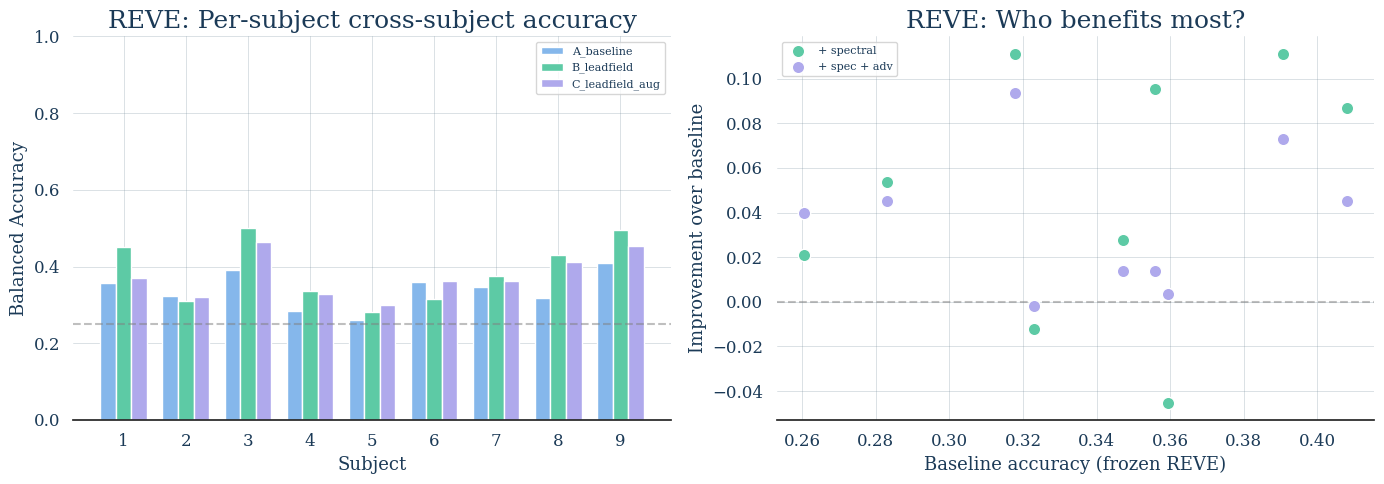

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(unique_subjects))
width = 0.25
colors = ['#85B7EB', '#5DCAA5', '#AFA9EC']

for i, (cond, color) in enumerate(zip(CONDITIONS, colors)):
    vals = [all_results[cond][s] for s in unique_subjects]
    ax.bar(x + i*width, vals, width, label=cond, color=color, edgecolor='white')

ax.set_xlabel('Subject')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('REVE: Per-subject cross-subject accuracy')
ax.set_xticks(x + width)
ax.set_xticklabels([str(s) for s in unique_subjects])
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5)

ax = axes[1]
base = np.array([all_results['A_baseline'][s] for s in unique_subjects])
spec = np.array([all_results['B_leadfield'][s] for s in unique_subjects])
full = np.array([all_results['C_leadfield_aug'][s] for s in unique_subjects])

ax.scatter(base, spec - base, s=80, c='#5DCAA5', label='+ leadfield', zorder=3, edgecolors='white')
ax.scatter(base, full - base, s=80, c='#AFA9EC', label='+ leadfield + jitter', zorder=3, edgecolors='white')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Baseline accuracy (frozen REVE)')
ax.set_ylabel('Improvement over baseline')
ax.set_title('REVE: Who benefits most?')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('reve_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Results for Cross-Model Comparison

Save results as JSON so you can load them alongside CBraMod results.

In [91]:
import json

# Convert numpy types for JSON serialization
results_serializable = {}
for cond, subj_dict in all_results.items():
    results_serializable[cond] = {str(k): float(v) for k, v in subj_dict.items()}

output = {
    'backbone': 'REVE-Base',
    'dataset': 'BCI-IV-2a',
    'evaluation': 'LOSO',
    'results': results_serializable,
}

with open('reve_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("Results saved to reve_results.json")
print("\nDownload this file and the CBraMod equivalent to compare backbones.")
print("\nKey comparison to make:")
print("  spectral_improvement_reve = REVE(+spectral) - REVE(baseline)")
print("  spectral_improvement_cbramod = CBraMod(+spectral) - CBraMod(baseline)")
print("  If spectral_improvement_reve > spectral_improvement_cbramod,")
print("  then REVE's raw-patch approach IS missing frequency information.")

Results saved to reve_results.json

Download this file and the CBraMod equivalent to compare backbones.

Key comparison to make:
  spectral_improvement_reve = REVE(+spectral) - REVE(baseline)
  spectral_improvement_cbramod = CBraMod(+spectral) - CBraMod(baseline)
  If spectral_improvement_reve > spectral_improvement_cbramod,
  then REVE's raw-patch approach IS missing frequency information.


## 11. Compare with PhysREVE Single-Subject Results

Load `reve_results.json` alongside the PhysREVE single-subject numbers to answer  
whether cross-subject REVE + spectral adapter beats within-subject PhysREVE fine-tuning.

In [93]:
# PhysREVE single-subject reference (subject 1, from quick_wins_notebook)
physreve_ref = {
    'lda_subject1':          0.581,
    'random_init_large':     0.407,
    'physreve_large':        0.407,
    'small_random_init':     0.442,
    'chance':                0.250,
}

print('=== Cross-model comparison ===')
print(f'{"Model":<35}  {"Acc":>6}')
print('-' * 45)
print(f'[PhysREVE env, subj 1 only]')
for k, v in physreve_ref.items():
    print(f'  {k:<33}  {v:.3f}')

print(f'\n[REVE LOSO — mean over 9 subjects]')
for cond in CONDITIONS:
    vals = list(all_results[cond].values())
    print(f'  {cond:<33}  {np.mean(vals):.3f}  (±{np.std(vals):.3f})')

print()
print('Key question:')
spec_delta = np.mean(list(all_results['B_leadfield'].values())) - np.mean(list(all_results['A_baseline'].values()))
adv_delta  = np.mean(list(all_results['C_leadfield_aug'].values())) - np.mean(list(all_results['B_leadfield'].values()))
print(f'  Spectral adapter Δ: {spec_delta:+.3f}  (REVE missing frequency info if positive)')
print(f'  Adversarial Δ:      {adv_delta:+.3f}  (subject alignment useful if positive)')


=== Cross-model comparison ===
Model                                   Acc
---------------------------------------------
[PhysREVE env, subj 1 only]
  lda_subject1                       0.581
  random_init_large                  0.407
  physreve_large                     0.407
  small_random_init                  0.442
  chance                             0.250

[REVE LOSO — mean over 9 subjects]
  A_baseline                         0.338  (±0.045)
  B_leadfield                        0.388  (±0.079)
  C_leadfield_aug                    0.375  (±0.054)

Key question:
  Spectral adapter Δ: +0.050  (REVE missing frequency info if positive)
  Adversarial Δ:      -0.014  (subject alignment useful if positive)
